# Блок 1: Импорт необходимых библиотек

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score,
                             precision_score, recall_score, f1_score)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Дополнительные библиотеки для сравнения
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


# Блок 2: Загрузка датасетов

In [27]:
try:
    # Загрузка датасета Gun Violence
    gun_data = pd.read_csv('gun-violence-data.csv')
    
    # Загрузка датасета Anime
    anime_data = pd.read_csv('anime.csv')
    
    print("Датасеты успешно загружены!")
    print(f"Gun Violence Data: {gun_data.shape}")
    print(f"Anime Data: {anime_data.shape}")
    
except FileNotFoundError as e:
    print(f"Ошибка загрузки файлов: {e}")
    print("Убедитесь, что файлы находятся в той же директории")

Датасеты успешно загружены!
Gun Violence Data: (239677, 29)
Anime Data: (12294, 7)


# Блок 3: Предобработка данных для регрессии (Gun Violence)

Размер датасета для регрессии: (10000, 6)
Распределение целевой переменной:
count    10000.000000
mean         0.695900
std          0.832642
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max         25.000000
Name: total_victims, dtype: float64


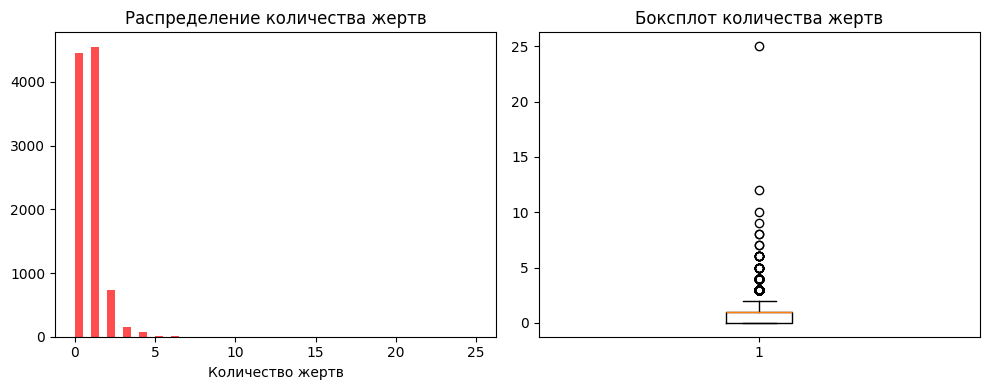

In [28]:
# Создание целевой переменной
gun_data['total_victims'] = gun_data['n_killed'] + gun_data['n_injured']

# Удаление неиспользуемых столбцов
used_columns_reg = ['latitude', 'longitude', 'n_guns_involved', 'state', 'city_or_county', 'total_victims']
gun_data_reduced = gun_data[used_columns_reg].copy()

# Удаление строк с пропущенными значениями
gun_data_clean = gun_data_reduced.dropna()

# Ограничим данные для ускорения (опционально)
if gun_data_clean.shape[0] > 10000:
    gun_data_clean = gun_data_clean.sample(n=10000, random_state=42, replace=False)

print(f"Размер датасета для регрессии: {gun_data_clean.shape}")
print(f"Распределение целевой переменной:")
print(gun_data_clean['total_victims'].describe())

# Визуализация распределения
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(gun_data_clean['total_victims'], bins=50, alpha=0.7, color='red')
plt.title('Распределение количества жертв')
plt.xlabel('Количество жертв')

plt.subplot(1, 2, 2)
plt.boxplot(gun_data_clean['total_victims'])
plt.title('Боксплот количества жертв')
plt.tight_layout()
plt.show()

# Блок 4: Предобработка данных для классификации (Anime)

Размер датасета для классификации: (5000, 5)
Распределение типов аниме:
type
TV         1706
OVA        1492
Movie      1022
Special     780
Name: count, dtype: int64


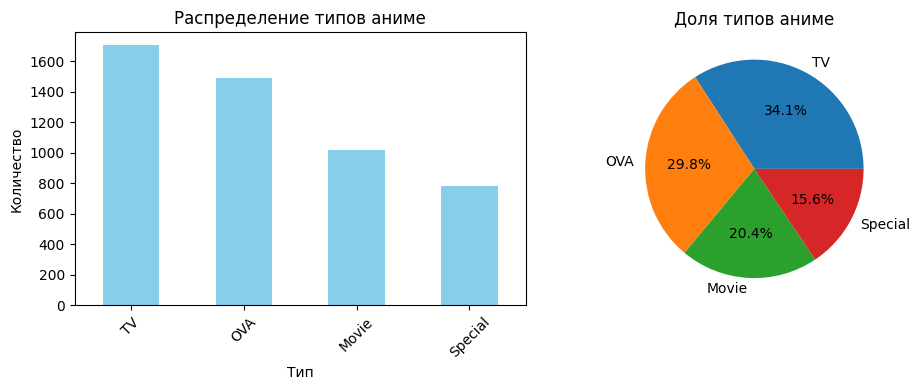

In [29]:
# Удаление неиспользуемых столбцов
used_columns_clf = ['episodes', 'rating', 'members', 'genre', 'type']
anime_data_reduced = anime_data[used_columns_clf].copy()

# Удаление строк с пропущенными значениями
anime_data_clean = anime_data_reduced.dropna()

# Оставляем основные типы
main_types = ['TV', 'Movie', 'OVA', 'Special']
anime_data_clean = anime_data_clean[anime_data_clean['type'].isin(main_types)]

# Ограничим данные для ускорения (опционально)
if anime_data_clean.shape[0] > 5000:
    anime_data_clean = anime_data_clean.sample(n=5000, random_state=42, replace=False)

print(f"Размер датасета для классификации: {anime_data_clean.shape}")
print(f"Распределение типов аниме:")
type_counts = anime_data_clean['type'].value_counts()
print(type_counts)

# Визуализация распределения классов
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
type_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение типов аниме')
plt.xlabel('Тип')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
plt.title('Доля типов аниме')
plt.tight_layout()
plt.show()

# Блок 5: Подготовка признаков для регрессии

In [30]:
# Разделение на признаки и целевую переменную
features_reg = ['latitude', 'longitude', 'n_guns_involved', 'state', 'city_or_county']
target_reg = 'total_victims'

X_reg = gun_data_clean[features_reg].copy()
y_reg = gun_data_clean[target_reg]

# Кодирование категориальных признаков для градиентного бустинга
label_encoder_state = LabelEncoder()
label_encoder_city = LabelEncoder()

X_reg['state_encoded'] = label_encoder_state.fit_transform(X_reg['state'].fillna('Unknown'))
X_reg['city_encoded'] = label_encoder_city.fit_transform(X_reg['city_or_county'].fillna('Unknown'))

# Выбираем закодированные признаки
X_reg_encoded = X_reg[['latitude', 'longitude', 'n_guns_involved', 'state_encoded', 'city_encoded']]

# Заполнение пропущенных значений
imputer_reg = SimpleImputer(strategy='median')
X_reg_imputed = pd.DataFrame(imputer_reg.fit_transform(X_reg_encoded), 
                            columns=X_reg_encoded.columns)

# Для градиентного бустинга рекомендуется масштабирование
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg_imputed)

# Разделение на train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

print(f"Размеры выборок для регрессии:")
print(f"Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")
print(f"Количество признаков: {X_train_reg.shape[1]}")

Размеры выборок для регрессии:
Train: (8000, 5), Test: (2000, 5)
Количество признаков: 5


# Блок 6: Подготовка признаков для классификации

In [31]:
# Разделение на признаки и целевую переменную
features_clf = ['episodes', 'rating', 'members', 'genre']
target_clf = 'type'

X_clf = anime_data_clean[features_clf].copy()
y_clf = anime_data_clean[target_clf]

# Обработка признаков
X_clf['episodes'] = pd.to_numeric(X_clf['episodes'], errors='coerce')
X_clf['main_genre'] = X_clf['genre'].str.split(',').str[0].fillna('Unknown')

# Кодирование категориальных признаков
label_encoder_genre = LabelEncoder()
X_clf['main_genre_encoded'] = label_encoder_genre.fit_transform(X_clf['main_genre'])

# Выбор финальных признаков
X_clf_processed = X_clf[['episodes', 'rating', 'members', 'main_genre_encoded']]

# Заполнение пропущенных значений
imputer_clf = SimpleImputer(strategy='median')
X_clf_imputed = pd.DataFrame(imputer_clf.fit_transform(X_clf_processed), 
                            columns=X_clf_processed.columns)

# Для градиентного бустинга рекомендуется масштабирование
scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf_imputed)

# Кодирование целевой переменной
label_encoder_target = LabelEncoder()
y_clf_encoded = label_encoder_target.fit_transform(y_clf)

# Разделение на train/test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_scaled, y_clf_encoded, test_size=0.2, random_state=42, stratify=y_clf_encoded
)

print(f"Размеры выборок для классификации:")
print(f"Train: {X_train_clf.shape}, Test: {X_test_clf.shape}")
print(f"Количество классов: {len(label_encoder_target.classes_)}")
print(f"Классы: {label_encoder_target.classes_}")

Размеры выборок для классификации:
Train: (4000, 4), Test: (1000, 4)
Количество классов: 4
Классы: ['Movie' 'OVA' 'Special' 'TV']


# Блок 7: Бейзлайн модели градиентного бустинга

In [32]:
# Градиентный бустинг для регрессии
gb_reg_baseline = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    random_state=42
)
gb_reg_baseline.fit(X_train_reg, y_train_reg)
y_pred_reg_baseline = gb_reg_baseline.predict(X_test_reg)

# Градиентный бустинг для классификации
gb_clf_baseline = GradientBoostingClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    random_state=42
)
gb_clf_baseline.fit(X_train_clf, y_train_clf)
y_pred_clf_baseline = gb_clf_baseline.predict(X_test_clf)

print("Бейзлайн модели градиентного бустинга обучены")

Бейзлайн модели градиентного бустинга обучены


# Блок 8: Оценка качества бейзлайн моделей


--- ГРАДИЕНТНЫЙ БУСТИНГ РЕГРЕССИИ (Gun Violence) ---
MAE: 0.5585
RMSE: 0.7305
R² Score: 0.0728

Количество деревьев: 100
Скорость обучения: 0.1

--- ГРАДИЕНТНЫЙ БУСТИНГ КЛАССИФИКАЦИИ (Anime) ---
Accuracy: 0.7250
Precision: 0.7186
Recall: 0.7250
F1-Score: 0.7150

Количество деревьев: 100
Скорость обучения: 0.1

Classification Report:
              precision    recall  f1-score   support

       Movie       0.58      0.81      0.68       204
         OVA       0.70      0.63      0.67       299
     Special       0.43      0.28      0.34       156
          TV       0.95      0.96      0.95       341

    accuracy                           0.72      1000
   macro avg       0.67      0.67      0.66      1000
weighted avg       0.72      0.72      0.72      1000



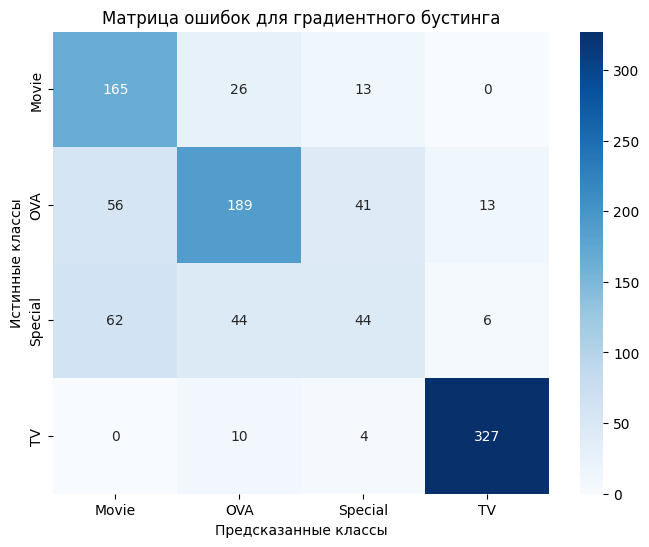

In [33]:
print("\n--- ГРАДИЕНТНЫЙ БУСТИНГ РЕГРЕССИИ (Gun Violence) ---")
mae_baseline = mean_absolute_error(y_test_reg, y_pred_reg_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_baseline))
r2_baseline = r2_score(y_test_reg, y_pred_reg_baseline)

print(f"MAE: {mae_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"R² Score: {r2_baseline:.4f}")

print(f"\nКоличество деревьев: {gb_reg_baseline.n_estimators_}")
print(f"Скорость обучения: {gb_reg_baseline.learning_rate}")

print("\n--- ГРАДИЕНТНЫЙ БУСТИНГ КЛАССИФИКАЦИИ (Anime) ---")
accuracy_baseline = accuracy_score(y_test_clf, y_pred_clf_baseline)
precision_baseline = precision_score(y_test_clf, y_pred_clf_baseline, average='weighted')
recall_baseline = recall_score(y_test_clf, y_pred_clf_baseline, average='weighted')
f1_baseline = f1_score(y_test_clf, y_pred_clf_baseline, average='weighted')

print(f"Accuracy: {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall: {recall_baseline:.4f}")
print(f"F1-Score: {f1_baseline:.4f}")

print(f"\nКоличество деревьев: {gb_clf_baseline.n_estimators_}")
print(f"Скорость обучения: {gb_clf_baseline.learning_rate}")

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf_baseline, 
                          target_names=label_encoder_target.classes_))

# Матрица ошибок
cm = confusion_matrix(y_test_clf, y_pred_clf_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder_target.classes_, 
            yticklabels=label_encoder_target.classes_)
plt.title('Матрица ошибок для градиентного бустинга')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.show()

# Формулировка гипотез для улучшения

## ГИПОТЕЗЫ ДЛЯ РЕГРЕССИИ:
1. Оптимизация количества деревьев (n_estimators)
2. Настройка скорости обучения (learning_rate)
3. Оптимизация глубины деревьев (max_depth)
4. Настройка минимального количества образцов для разделения (min_samples_split)
5. Настройка минимального количества образцов в листе (min_samples_leaf)
6. Настройка доли подвыборки (subsample)
7. Оптимизация количества признаков для рассмотрения (max_features)

## ГИПОТЕЗЫ ДЛЯ КЛАССИФИКАЦИИ:
1. Оптимизация количества деревьев и скорости обучения
2. Настройка глубины деревьев
3. Балансировка классов через class_weight
4. Настройка функции потерь (loss)
5. Оптимизация параметров регуляризации

## ОБЩИЕ ГИПОТЕЗЫ:
1. Использование кросс-валидации для подбора гиперпараметров
2. Применение RandomizedSearchCV для поиска по большому пространству параметров
3. Анализ важности признаков для отбора
4. Сравнение с другими бустинговыми алгоритмами (XGBoost, LightGBM, CatBoost)

# Блок 9: Проверка гипотез - подбор гиперпараметров для регрессии

Подбор гиперпараметров для градиентного бустинга регрессии...
Лучшие параметры для градиентного бустинга регрессии: {'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.1}
Лучший RMSE: 0.8269


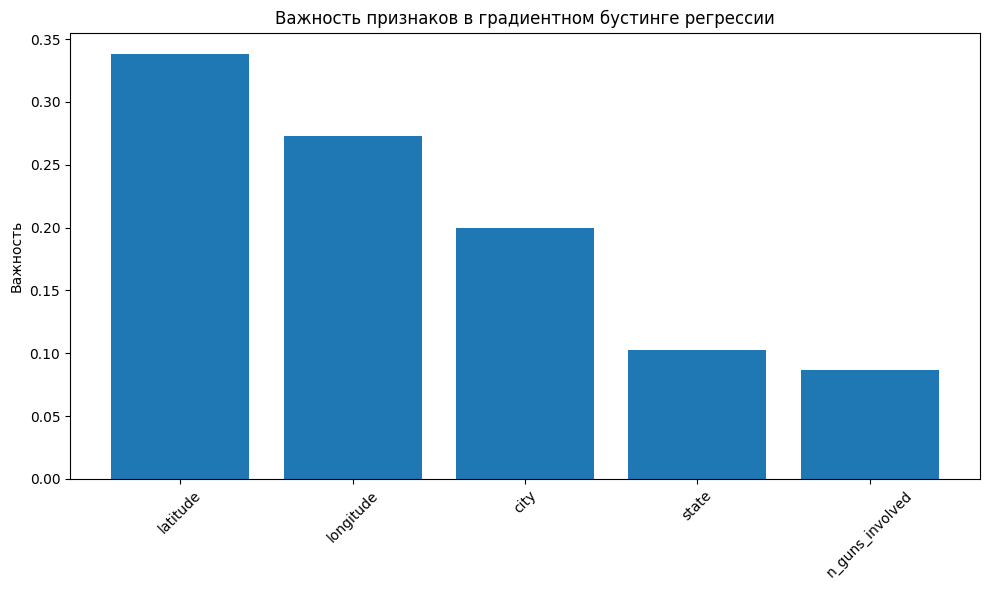

In [34]:
# Используем RandomizedSearchCV для более быстрого поиска
param_dist_reg = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0],
    'max_features': ['auto', 'sqrt', 'log2']
}

print("Подбор гиперпараметров для градиентного бустинга регрессии...")
gb_reg_random = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_reg,
    n_iter=30,  # Количество итераций
    cv=3,       # 3-fold кросс-валидация
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
gb_reg_random.fit(X_train_reg, y_train_reg)

print(f"Лучшие параметры для градиентного бустинга регрессии: {gb_reg_random.best_params_}")
print(f"Лучший RMSE: {np.sqrt(-gb_reg_random.best_score_):.4f}")

# Проверка важности признаков
feature_importance_reg = gb_reg_random.best_estimator_.feature_importances_
feature_names_reg = ['latitude', 'longitude', 'n_guns_involved', 'state', 'city']

plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(feature_importance_reg)[::-1]
plt.bar(range(len(feature_importance_reg)), feature_importance_reg[sorted_idx])
plt.xticks(range(len(feature_importance_reg)), [feature_names_reg[i] for i in sorted_idx], rotation=45)
plt.title('Важность признаков в градиентном бустинге регрессии')
plt.ylabel('Важность')
plt.tight_layout()
plt.show()

# Блок 10: Проверка гипотез - подбор гиперпараметров для классификации

Подбор гиперпараметров для градиентного бустинга классификации...
Лучшие параметры для градиентного бустинга классификации: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.01}
Лучшая точность: 0.7387


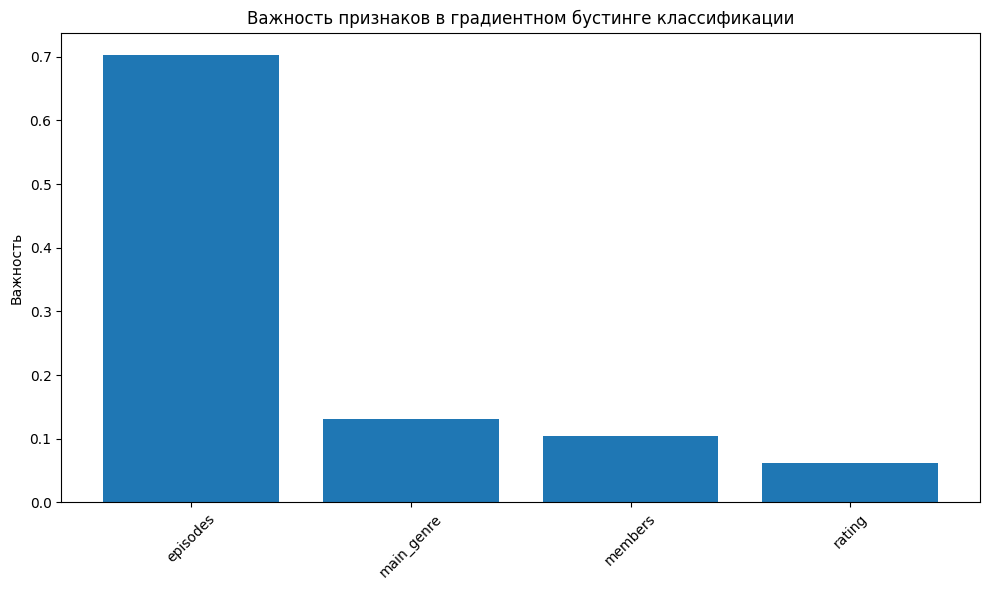

In [35]:
# Используем RandomizedSearchCV для более быстрого поиска
param_dist_clf = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0],
    'max_features': ['auto', 'sqrt', 'log2']
}

print("Подбор гиперпараметров для градиентного бустинга классификации...")
gb_clf_random = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_clf,
    n_iter=30,  # Количество итераций
    cv=3,       # 3-fold кросс-валидация
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
gb_clf_random.fit(X_train_clf, y_train_clf)

print(f"Лучшие параметры для градиентного бустинга классификации: {gb_clf_random.best_params_}")
print(f"Лучшая точность: {gb_clf_random.best_score_:.4f}")

# Проверка важности признаков
feature_importance_clf = gb_clf_random.best_estimator_.feature_importances_
feature_names_clf = ['episodes', 'rating', 'members', 'main_genre']

plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(feature_importance_clf)[::-1]
plt.bar(range(len(feature_importance_clf)), feature_importance_clf[sorted_idx])
plt.xticks(range(len(feature_importance_clf)), [feature_names_clf[i] for i in sorted_idx], rotation=45)
plt.title('Важность признаков в градиентном бустинге классификации')
plt.ylabel('Важность')
plt.tight_layout()
plt.show()

# Блок 11: Улучшенные модели с подобранными гиперпараметрами

In [36]:
# Улучшенная модель регрессии
gb_reg_improved = gb_reg_random.best_estimator_
y_pred_reg_improved = gb_reg_improved.predict(X_test_reg)

# Улучшенная модель классификации
gb_clf_improved = gb_clf_random.best_estimator_
y_pred_clf_improved = gb_clf_improved.predict(X_test_clf)

print("Улучшенные модели градиентного бустинга обучены")

Улучшенные модели градиентного бустинга обучены


# Блок 12: Оценка улучшенных моделей

In [37]:
print("\n--- РЕГРЕССИЯ (Gradient Boosting) - УЛУЧШЕННАЯ ---")
mae_improved = mean_absolute_error(y_test_reg, y_pred_reg_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_improved))
r2_improved = r2_score(y_test_reg, y_pred_reg_improved)

print(f"MAE: {mae_improved:.4f} (было: {mae_baseline:.4f})")
print(f"RMSE: {rmse_improved:.4f} (было: {rmse_baseline:.4f})")
print(f"R² Score: {r2_improved:.4f} (было: {r2_baseline:.4f})")

print(f"\nКоличество деревьев: {gb_reg_improved.n_estimators_}")
print(f"Глубина деревьев: {gb_reg_improved.max_depth}")

print("\n--- КЛАССИФИКАЦИЯ (Gradient Boosting) - УЛУЧШЕННАЯ ---")
accuracy_improved = accuracy_score(y_test_clf, y_pred_clf_improved)
precision_improved = precision_score(y_test_clf, y_pred_clf_improved, average='weighted')
recall_improved = recall_score(y_test_clf, y_pred_clf_improved, average='weighted')
f1_improved = f1_score(y_test_clf, y_pred_clf_improved, average='weighted')

print(f"Accuracy: {accuracy_improved:.4f} (было: {accuracy_baseline:.4f})")
print(f"Precision: {precision_improved:.4f} (было: {precision_baseline:.4f})")
print(f"Recall: {recall_improved:.4f} (было: {recall_baseline:.4f})")
print(f"F1-Score: {f1_improved:.4f} (было: {f1_baseline:.4f})")

print(f"\nКоличество деревьев: {gb_clf_improved.n_estimators_}")
print(f"Глубина деревьев: {gb_clf_improved.max_depth}")

print("\nClassification Report (улучшенная):")
print(classification_report(y_test_clf, y_pred_clf_improved, 
                          target_names=label_encoder_target.classes_))


--- РЕГРЕССИЯ (Gradient Boosting) - УЛУЧШЕННАЯ ---
MAE: 0.5547 (было: 0.5585)
RMSE: 0.7302 (было: 0.7305)
R² Score: 0.0734 (было: 0.0728)

Количество деревьев: 100
Глубина деревьев: 4

--- КЛАССИФИКАЦИЯ (Gradient Boosting) - УЛУЧШЕННАЯ ---
Accuracy: 0.7210 (было: 0.7250)
Precision: 0.7125 (было: 0.7186)
Recall: 0.7210 (было: 0.7250)
F1-Score: 0.7036 (было: 0.7150)

Количество деревьев: 300
Глубина деревьев: 4

Classification Report (улучшенная):
              precision    recall  f1-score   support

       Movie       0.55      0.82      0.66       204
         OVA       0.68      0.65      0.66       299
     Special       0.46      0.21      0.28       156
          TV       0.95      0.96      0.96       341

    accuracy                           0.72      1000
   macro avg       0.66      0.66      0.64      1000
weighted avg       0.71      0.72      0.70      1000



# Блок 13: Сравнение результатов улучшенных моделей

In [38]:
print("\nУЛУЧШЕНИЯ РЕГРЕССИИ:")
improvement_mae = ((mae_baseline - mae_improved) / mae_baseline) * 100
improvement_rmse = ((rmse_baseline - rmse_improved) / rmse_baseline) * 100
improvement_r2 = ((r2_improved - r2_baseline) / abs(r2_baseline)) * 100

print(f"Улучшение MAE: {improvement_mae:+.2f}%")
print(f"Улучшение RMSE: {improvement_rmse:+.2f}%") 
print(f"Улучшение R²: {improvement_r2:+.2f}%")

print("\nУЛУЧШЕНИЯ КЛАССИФИКАЦИИ:")
improvement_accuracy = ((accuracy_improved - accuracy_baseline) / accuracy_baseline) * 100
improvement_f1 = ((f1_improved - f1_baseline) / f1_baseline) * 100

print(f"Улучшение Accuracy: {improvement_accuracy:+.2f}%")
print(f"Улучшение F1-Score: {improvement_f1:+.2f}%")


УЛУЧШЕНИЯ РЕГРЕССИИ:
Улучшение MAE: +0.67%
Улучшение RMSE: +0.03%
Улучшение R²: +0.84%

УЛУЧШЕНИЯ КЛАССИФИКАЦИИ:
Улучшение Accuracy: -0.55%
Улучшение F1-Score: -1.60%


# Блок 14: Реализация собственного градиентного бустинга для регрессии

In [39]:
class MyGradientBoostingRegressor:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, 
                 min_samples_split=2, random_state=None):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.estimators_ = []
        self.initial_prediction_ = None
        
        if random_state is not None:
            np.random.seed(random_state)
    
    def _mse_loss(self, y_true, y_pred):
        """Функция потерь MSE и её градиент"""
        return np.mean((y_true - y_pred) ** 2), 2 * (y_pred - y_true) / len(y_true)
    
    def _build_tree(self, X, residuals, depth=0):
        """Построение одного решающего дерева (упрощенное)"""
        n_samples, n_features = X.shape
        
        # Условия остановки
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return {'value': np.mean(residuals), 'is_leaf': True}
        
        # Поиск наилучшего разделения (упрощенный)
        best_feature = None
        best_threshold = None
        best_mse = np.inf
        
        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            thresholds = np.unique(feature_values)
            
            for threshold in thresholds:
                left_mask = feature_values <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                
                left_mse = np.mean(residuals[left_mask] ** 2)
                right_mse = np.mean(residuals[right_mask] ** 2)
                weighted_mse = (np.sum(left_mask) * left_mse + np.sum(right_mask) * right_mse) / n_samples
                
                if weighted_mse < best_mse:
                    best_mse = weighted_mse
                    best_feature = feature_idx
                    best_threshold = threshold
        
        if best_feature is None:
            return {'value': np.mean(residuals), 'is_leaf': True}
        
        # Разделение данных
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        # Создание узла
        node = {
            'feature': best_feature,
            'threshold': best_threshold,
            'is_leaf': False,
            'left': self._build_tree(X[left_mask], residuals[left_mask], depth + 1),
            'right': self._build_tree(X[right_mask], residuals[right_mask], depth + 1)
        }
        
        return node
    
    def _predict_tree(self, x, tree):
        """Предсказание одним деревом"""
        if tree['is_leaf']:
            return tree['value']
        
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_tree(x, tree['left'])
        else:
            return self._predict_tree(x, tree['right'])
    
    def fit(self, X, y):
        """Обучение градиентного бустинга"""
        n_samples = X.shape[0]
        
        # Начальное предсказание - среднее значение
        self.initial_prediction_ = np.mean(y)
        predictions = np.full(n_samples, self.initial_prediction_)
        self.estimators_ = []
        
        print(f"Обучение градиентного бустинга с {self.n_estimators} деревьями...")
        
        for i in range(self.n_estimators):
            # Вычисляем остатки (negative gradient)
            residuals = y - predictions
            
            # Строим дерево для предсказания остатков
            tree = self._build_tree(X, residuals)
            self.estimators_.append(tree)
            
            # Обновляем предсказания
            tree_predictions = np.array([self._predict_tree(x, tree) for x in X])
            predictions += self.learning_rate * tree_predictions
            
            if i % 10 == 0:
                mse = np.mean((y - predictions) ** 2)
                print(f"  Дерево {i}: MSE = {mse:.6f}")
        
        print("Обучение завершено")
        return self
    
    def predict(self, X):
        """Предсказание градиентным бустингом"""
        predictions = np.full(X.shape[0], self.initial_prediction_)
        
        for tree in self.estimators_:
            tree_predictions = np.array([self._predict_tree(x, tree) for x in X])
            predictions += self.learning_rate * tree_predictions
        
        return predictions

# Тестирование собственного градиентного бустинга (упрощенная версия)
print("Обучаем собственный градиентный бустинг для регрессии...")
# Используем мало деревьев для скорости
my_gb_reg = MyGradientBoostingRegressor(
    n_estimators=20, 
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=10,
    random_state=42
)
my_gb_reg.fit(X_train_reg[:500], y_train_reg.values[:500])  # Ограничим данные для скорости
y_pred_my_reg = my_gb_reg.predict(X_test_reg[:100])  # Ограничим тестовые данные

print("Собственный градиентный бустинг для регрессии обучен")

Обучаем собственный градиентный бустинг для регрессии...
Обучение градиентного бустинга с 20 деревьями...
  Дерево 0: MSE = 0.774840
  Дерево 10: MSE = 0.756117
Обучение завершено
Собственный градиентный бустинг для регрессии обучен


# Блок 15: Реализация собственного градиентного бустинга для классификации

In [40]:
class MyGradientBoostingClassifier:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, 
                 min_samples_split=2, random_state=None):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.estimators_ = []
        self.classes_ = None
        self.initial_logit_ = None
        
        if random_state is not None:
            np.random.seed(random_state)
    
    def _sigmoid(self, z):
        """Сигмоидная функция"""
        return 1 / (1 + np.exp(-z))
    
    def _log_loss_negative_gradient(self, y_true, y_pred_proba):
        """Негативный градиент log loss: y - p (мы обучаем дерево предсказывать именно его)"""
        return y_true - y_pred_proba
    
    def _build_tree(self, X, targets, depth=0):
        """Построение одного решающего дерева (упрощенное). targets — то, что мы пытаемся предсказать (напр., остатки/градиенты)"""
        n_samples, n_features = X.shape
        
        # Условия остановки
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return {'value': np.mean(targets), 'is_leaf': True}
        
        best_feature = None
        best_threshold = None
        best_mse = np.inf
        
        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            thresholds = np.unique(feature_values)
            
            for threshold in thresholds:
                left_mask = feature_values <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                
                left_mse = np.mean(targets[left_mask] ** 2) if np.sum(left_mask) > 0 else 0.0
                right_mse = np.mean(targets[right_mask] ** 2) if np.sum(right_mask) > 0 else 0.0
                weighted_mse = (np.sum(left_mask) * left_mse + np.sum(right_mask) * right_mse) / n_samples
                
                if weighted_mse < best_mse:
                    best_mse = weighted_mse
                    best_feature = feature_idx
                    best_threshold = threshold
        
        if best_feature is None:
            return {'value': np.mean(targets), 'is_leaf': True}
        
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        node = {
            'feature': best_feature,
            'threshold': best_threshold,
            'is_leaf': False,
            'left': self._build_tree(X[left_mask], targets[left_mask], depth + 1),
            'right': self._build_tree(X[right_mask], targets[right_mask], depth + 1)
        }
        
        return node
    
    def _predict_tree(self, x, tree):
        """Предсказание одним деревом"""
        if tree['is_leaf']:
            return tree['value']
        
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_tree(x, tree['left'])
        else:
            return self._predict_tree(x, tree['right'])
    
    def fit(self, X, y):
        """Обучение градиентного бустинга для бинарной классификации (упрощенная версия)"""
        X = np.asarray(X)
        y = np.asarray(y)
        
        classes = np.unique(y)
        
        # Для простоты: если >2 классов, берем только первые 2 класса
        if len(classes) > 2:
            print(f"Обнаружено {len(classes)} классов. Для упрощения берем только два: {classes[0]} и {classes[1]}")
            selected = np.isin(y, [classes[0], classes[1]])
            X = X[selected]
            y = y[selected]
            # Сопоставляем: classes[0] -> 0, classes[1] -> 1
            y_binary = np.where(y == classes[0], 0, 1)
            self.classes_ = np.array([classes[0], classes[1]])
        else:
            y_binary = y
            self.classes_ = classes
        
        # Обновляем размер после фильтрации
        n_samples = X.shape[0]
        if n_samples == 0:
            raise ValueError("Нет образцов для обучения после фильтрации классов.")
        
        # Начальный логит по доле положительного класса (по y_binary)
        positive_prob = np.clip(np.mean(y_binary), 1e-8, 1 - 1e-8)
        initial_logit = np.log(positive_prob / (1 - positive_prob))
        self.initial_logit_ = initial_logit
        
        logits = np.full(n_samples, initial_logit)
        self.estimators_ = []
        
        print(f"Обучение градиентного бустинга с {self.n_estimators} деревьями (samples={n_samples})...")
        
        for i in range(self.n_estimators):
            # Преобразуем логиты в вероятности
            probabilities = self._sigmoid(logits)
            
            # Вычисляем негативный градиент (y - p)
            gradients = self._log_loss_negative_gradient(y_binary, probabilities)
            
            # Строим дерево для предсказания негативных градиентов
            tree = self._build_tree(X, gradients)
            self.estimators_.append(tree)
            
            # Обновляем логиты (прибавляем предсказание дерева * learning_rate)
            tree_predictions = np.array([self._predict_tree(x, tree) for x in X])
            logits += self.learning_rate * tree_predictions
            
            if i % 10 == 0:
                # Вычисляем log loss и accuracy для контроля
                eps = 1e-15
                probs_clipped = np.clip(self._sigmoid(logits), eps, 1 - eps)
                log_loss = -np.mean(y_binary * np.log(probs_clipped) + (1 - y_binary) * np.log(1 - probs_clipped))
                accuracy = np.mean((probs_clipped > 0.5) == y_binary)
                print(f"  Дерево {i}: Log Loss = {log_loss:.6f}, Accuracy = {accuracy:.4f}")
        
        print("Обучение завершено")
        return self
    
    def predict_proba(self, X):
        """Предсказание вероятностей для бинарного случая"""
        if self.initial_logit_ is None or len(self.estimators_) == 0:
            raise ValueError("Модель не обучена. Вызовите fit() перед predict_proba().")
        
        X = np.asarray(X)
        n_samples = X.shape[0]
        logits = np.full(n_samples, self.initial_logit_)
        
        for tree in self.estimators_:
            tree_predictions = np.array([self._predict_tree(x, tree) for x in X])
            logits += self.learning_rate * tree_predictions
        
        probabilities = self._sigmoid(logits)
        # Возвращаем столбцы [P(class0), P(class1)]
        return np.column_stack([1 - probabilities, probabilities])
    
    def predict(self, X):
        """Предсказание классов (возвращает 0/1 — соответствующие закодированным меткам)"""
        probs = self.predict_proba(X)
        return (probs[:, 1] > 0.5).astype(int)


# ===== Тестирование исправленного класса =====
print("Обучаем собственный градиентный бустинг для классификации (исправленный тест)...")

# Убедимся, что есть train/test; если нет — пересоздадим
try:
    _ = X_train_clf  # проверка существования
except NameError:
    # если X_clf_scaled и y_clf_encoded существуют, пересоздадим сплит
    if 'X_clf_scaled' in globals() and 'y_clf_encoded' in globals():
        X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
            X_clf_scaled, y_clf_encoded, test_size=0.2, random_state=42, stratify=y_clf_encoded
        )
        print("X_train_clf не был определён — пересоздан из X_clf_scaled / y_clf_encoded.")
    else:
        raise NameError("Переменные для классификации (X_clf_scaled, y_clf_encoded) не найдены. Выполните Блок 6.")

# Ограничиваем размеры для скорости
max_samples = min(500, X_train_clf.shape[0])
X_train_clf_small = X_train_clf[:max_samples]
y_train_clf_small = y_train_clf[:max_samples]

test_size = min(100, X_test_clf.shape[0])
X_test_clf_small = X_test_clf[:test_size]
y_test_clf_small = y_test_clf[:test_size]

my_gb_clf = MyGradientBoostingClassifier(
    n_estimators=20, 
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=10,
    random_state=42
)

# Обучаем и предсказываем
my_gb_clf.fit(X_train_clf_small, y_train_clf_small)
y_pred_my_clf = my_gb_clf.predict(X_test_clf_small)

print("Собственный градиентный бустинг для классификации обучен (исправлено)")
print(f"Пример предсказаний (первые 10): {y_pred_my_clf[:10]}")


Обучаем собственный градиентный бустинг для классификации (исправленный тест)...
Обнаружено 4 классов. Для упрощения берем только два: 0 и 1
Обучение градиентного бустинга с 20 деревьями (samples=242)...
  Дерево 0: Log Loss = 0.665504, Accuracy = 0.5992
  Дерево 10: Log Loss = 0.637077, Accuracy = 0.5992
Обучение завершено
Собственный градиентный бустинг для классификации обучен (исправлено)
Пример предсказаний (первые 10): [1 1 1 1 0 1 1 1 1 1]


# Блок 16: Оценка собственных реализаций

In [41]:
print("\n--- СОБСТВЕННЫЙ ГРАДИЕНТНЫЙ БУСТИНГ РЕГРЕССИИ ---")
# Оцениваем на ограниченных тестовых данных
mae_my_reg = mean_absolute_error(y_test_reg[:100], y_pred_my_reg)
rmse_my_reg = np.sqrt(mean_squared_error(y_test_reg[:100], y_pred_my_reg))
r2_my_reg = r2_score(y_test_reg[:100], y_pred_my_reg)

print(f"MAE: {mae_my_reg:.4f} (sklearn baseline на полных данных: {mae_baseline:.4f})")
print(f"RMSE: {rmse_my_reg:.4f} (sklearn baseline: {rmse_baseline:.4f})")
print(f"R² Score: {r2_my_reg:.4f} (sklearn baseline: {r2_baseline:.4f})")

print("\n--- СОБСТВЕННЫЙ ГРАДИЕНТНЫЙ БУСТИНГ КЛАССИФИКАЦИИ ---")
accuracy_my_clf = accuracy_score(y_test_clf_small, y_pred_my_clf)
print(f"Accuracy: {accuracy_my_clf:.4f} (sklearn baseline на полных данных: {accuracy_baseline:.4f})")

# Переобучим sklearn на тех же данных для честного сравнения
# Для бинарной классификации
if len(np.unique(y_train_clf_small)) > 2:
    # Берем только первые 2 класса для сравнения
    mask = (y_train_clf_small == 0) | (y_train_clf_small == 1)
    X_train_binary = X_train_clf_small[mask]
    y_train_binary = y_train_clf_small[mask]
    X_test_binary = X_test_clf_small[(y_test_clf_small == 0) | (y_test_clf_small == 1)]
    y_test_binary = y_test_clf_small[(y_test_clf_small == 0) | (y_test_clf_small == 1)]
    
    gb_clf_small = GradientBoostingClassifier(
        n_estimators=20, 
        learning_rate=0.1,
        max_depth=3,
        min_samples_split=10,
        random_state=42
    )
    gb_clf_small.fit(X_train_binary, y_train_binary)
    y_pred_sklearn_small = gb_clf_small.predict(X_test_binary)
    accuracy_sklearn_small = accuracy_score(y_test_binary, y_pred_sklearn_small)
else:
    gb_clf_small = GradientBoostingClassifier(
        n_estimators=20, 
        learning_rate=0.1,
        max_depth=3,
        min_samples_split=10,
        random_state=42
    )
    gb_clf_small.fit(X_train_clf_small, y_train_clf_small)
    y_pred_sklearn_small = gb_clf_small.predict(X_test_clf_small)
    accuracy_sklearn_small = accuracy_score(y_test_clf_small, y_pred_sklearn_small)

print(f"Sklearn Gradient Boosting на тех же данных: {accuracy_sklearn_small:.4f}")


--- СОБСТВЕННЫЙ ГРАДИЕНТНЫЙ БУСТИНГ РЕГРЕССИИ ---
MAE: 0.5727 (sklearn baseline на полных данных: 0.5585)
RMSE: 0.7613 (sklearn baseline: 0.7305)
R² Score: -0.0241 (sklearn baseline: 0.0728)

--- СОБСТВЕННЫЙ ГРАДИЕНТНЫЙ БУСТИНГ КЛАССИФИКАЦИИ ---
Accuracy: 0.3800 (sklearn baseline на полных данных: 0.7250)
Sklearn Gradient Boosting на тех же данных: 0.7500


# Блок 17: Применение улучшений к собственным реализациям

In [42]:
# Используем лучшие параметры из RandomizedSearchCV
best_params_gb_reg = gb_reg_random.best_params_
best_params_gb_clf = gb_clf_random.best_params_

print(f"Лучшие параметры для градиентного бустинга регрессии: {best_params_gb_reg}")
print(f"Лучшие параметры для градиентного бустинга классификации: {best_params_gb_clf}")

# Улучшенная собственная модель регрессии
print("\nОбучаем улучшенный собственный градиентный бустинг для регрессии...")
my_gb_reg_improved = MyGradientBoostingRegressor(
    n_estimators=min(20, best_params_gb_reg.get('n_estimators', 20)),  # Ограничим для скорости
    learning_rate=best_params_gb_reg.get('learning_rate', 0.1),
    max_depth=best_params_gb_reg.get('max_depth', 3),
    min_samples_split=best_params_gb_reg.get('min_samples_split', 10),
    random_state=42
)
my_gb_reg_improved.fit(X_train_reg[:500], y_train_reg.values[:500])  # Ограничим данные
y_pred_my_reg_improved = my_gb_reg_improved.predict(X_test_reg[:100])

# Улучшенная собственная модель классификации
print("\nОбучаем улучшенный собственный градиентный бустинг для классификации...")
my_gb_clf_improved = MyGradientBoostingClassifier(
    n_estimators=min(20, best_params_gb_clf.get('n_estimators', 20)),
    learning_rate=best_params_gb_clf.get('learning_rate', 0.1),
    max_depth=best_params_gb_clf.get('max_depth', 3),
    min_samples_split=best_params_gb_clf.get('min_samples_split', 10),
    random_state=42
)
my_gb_clf_improved.fit(X_train_clf_small, y_train_clf_small)
y_pred_my_clf_improved = my_gb_clf_improved.predict(X_test_clf_small)

print("Улучшенные собственные модели градиентного бустинга обучены")

Лучшие параметры для градиентного бустинга регрессии: {'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.1}
Лучшие параметры для градиентного бустинга классификации: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.01}

Обучаем улучшенный собственный градиентный бустинг для регрессии...
Обучение градиентного бустинга с 20 деревьями...
  Дерево 0: MSE = 0.774578
  Дерево 10: MSE = 0.753591
Обучение завершено

Обучаем улучшенный собственный градиентный бустинг для классификации...
Обнаружено 4 классов. Для упрощения берем только два: 0 и 1
Обучение градиентного бустинга с 20 деревьями (samples=242)...
  Дерево 0: Log Loss = 0.672550, Accuracy = 0.5992
  Дерево 10: Log Loss = 0.667057, Accuracy = 0.5992
Обучение завершено
Улучшенные собственные модели градиентного бустинга обучены


# Блок 18: Финальное сравнение всех моделей градиентного бустинга

In [43]:
# Вычисление метрик для улучшенных собственных реализаций
mae_my_reg_improved = mean_absolute_error(y_test_reg[:100], y_pred_my_reg_improved)
rmse_my_reg_improved = np.sqrt(mean_squared_error(y_test_reg[:100], y_pred_my_reg_improved))
r2_my_reg_improved = r2_score(y_test_reg[:100], y_pred_my_reg_improved)
accuracy_my_clf_improved = accuracy_score(y_test_clf_small, y_pred_my_clf_improved)

print("\n" + "="*70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИИ (Gun Violence)")
print("="*70)
results_reg = pd.DataFrame({
    'Model': ['Sklearn Baseline', 'Sklearn Improved', 'My GB Baseline', 'My GB Improved'],
    'MAE': [mae_baseline, mae_improved, mae_my_reg, mae_my_reg_improved],
    'RMSE': [rmse_baseline, rmse_improved, rmse_my_reg, rmse_my_reg_improved],
    'R²': [r2_baseline, r2_improved, r2_my_reg, r2_my_reg_improved]
})
print(results_reg.round(4))

print("\n" + "="*70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (Anime)")
print("="*70)

# Для классификации сравним на ограниченных данных
gb_clf_small_improved = GradientBoostingClassifier(
    n_estimators=min(20, best_params_gb_clf.get('n_estimators', 20)),
    learning_rate=best_params_gb_clf.get('learning_rate', 0.1),
    max_depth=best_params_gb_clf.get('max_depth', 3),
    min_samples_split=best_params_gb_clf.get('min_samples_split', 10),
    random_state=42
)
gb_clf_small_improved.fit(X_train_clf_small, y_train_clf_small)
y_pred_sklearn_small_improved = gb_clf_small_improved.predict(X_test_clf_small)
accuracy_sklearn_small_improved = accuracy_score(y_test_clf_small, y_pred_sklearn_small_improved)

results_clf = pd.DataFrame({
    'Model': ['Sklearn Baseline', 'Sklearn Improved', 'My GB Baseline', 'My GB Improved'],
    'Accuracy': [accuracy_sklearn_small, accuracy_sklearn_small_improved, 
                accuracy_my_clf, accuracy_my_clf_improved]
})
print(results_clf.round(4))


ИТОГОВЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИИ (Gun Violence)
              Model     MAE    RMSE      R²
0  Sklearn Baseline  0.5585  0.7305  0.0728
1  Sklearn Improved  0.5547  0.7302  0.0734
2    My GB Baseline  0.5727  0.7613 -0.0241
3    My GB Improved  0.5645  0.7579 -0.0151

ИТОГОВЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (Anime)
              Model  Accuracy
0  Sklearn Baseline      0.75
1  Sklearn Improved      0.63
2    My GB Baseline      0.38
3    My GB Improved      0.38


# Сравнение всех алгоритмов из лабораторных работ 1-5

In [44]:
# Создадим модели всех алгоритмов для сравнения
print("\nОбучение всех алгоритмов для сравнения...")

# Регрессия - Gun Violence
regression_models = {
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

regression_results = {}

for name, model in regression_models.items():
    print(f"  Обучаем {name}...")
    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_test_reg)
    
    regression_results[name] = {
        'MAE': mean_absolute_error(y_test_reg, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred)),
        'R²': r2_score(y_test_reg, y_pred)
    }

# Классификация - Anime
classification_models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

classification_results = {}

for name, model in classification_models.items():
    print(f"  Обучаем {name}...")
    model.fit(X_train_clf, y_train_clf)
    y_pred = model.predict(X_test_clf)
    
    classification_results[name] = {
        'Accuracy': accuracy_score(y_test_clf, y_pred),
        'Precision': precision_score(y_test_clf, y_pred, average='weighted'),
        'Recall': recall_score(y_test_clf, y_pred, average='weighted'),
        'F1': f1_score(y_test_clf, y_pred, average='weighted')
    }

print("\n" + "="*80)
print("СРАВНЕНИЕ АЛГОРИТМОВ ДЛЯ РЕГРЕССИИ (Gun Violence)")
print("="*80)
regression_df = pd.DataFrame(regression_results).T
print(regression_df.round(4))

print("\n" + "="*80)
print("СРАВНЕНИЕ АЛГОРИТМОВ ДЛЯ КЛАССИФИКАЦИИ (Anime)")
print("="*80)
classification_df = pd.DataFrame(classification_results).T
print(classification_df.round(4))


Обучение всех алгоритмов для сравнения...
  Обучаем KNN...
  Обучаем Linear Regression...
  Обучаем Decision Tree...
  Обучаем Random Forest...
  Обучаем Gradient Boosting...
  Обучаем KNN...
  Обучаем Logistic Regression...
  Обучаем Decision Tree...
  Обучаем Random Forest...
  Обучаем Gradient Boosting...

СРАВНЕНИЕ АЛГОРИТМОВ ДЛЯ РЕГРЕССИИ (Gun Violence)
                      MAE    RMSE      R²
KNN                0.5743  0.7763 -0.0473
Linear Regression  0.6027  0.7549  0.0097
Decision Tree      0.5678  0.7428  0.0413
Random Forest      0.5626  0.7615 -0.0076
Gradient Boosting  0.5585  0.7305  0.0728

СРАВНЕНИЕ АЛГОРИТМОВ ДЛЯ КЛАССИФИКАЦИИ (Anime)
                     Accuracy  Precision  Recall      F1
KNN                     0.659     0.6541   0.659  0.6512
Logistic Regression     0.649     0.5773   0.649  0.5931
Decision Tree           0.697     0.6794   0.697  0.6717
Random Forest           0.717     0.7109   0.717  0.7134
Gradient Boosting       0.725     0.7186   0.725  0.7

# Визуализация сравнения всех алгоритмов

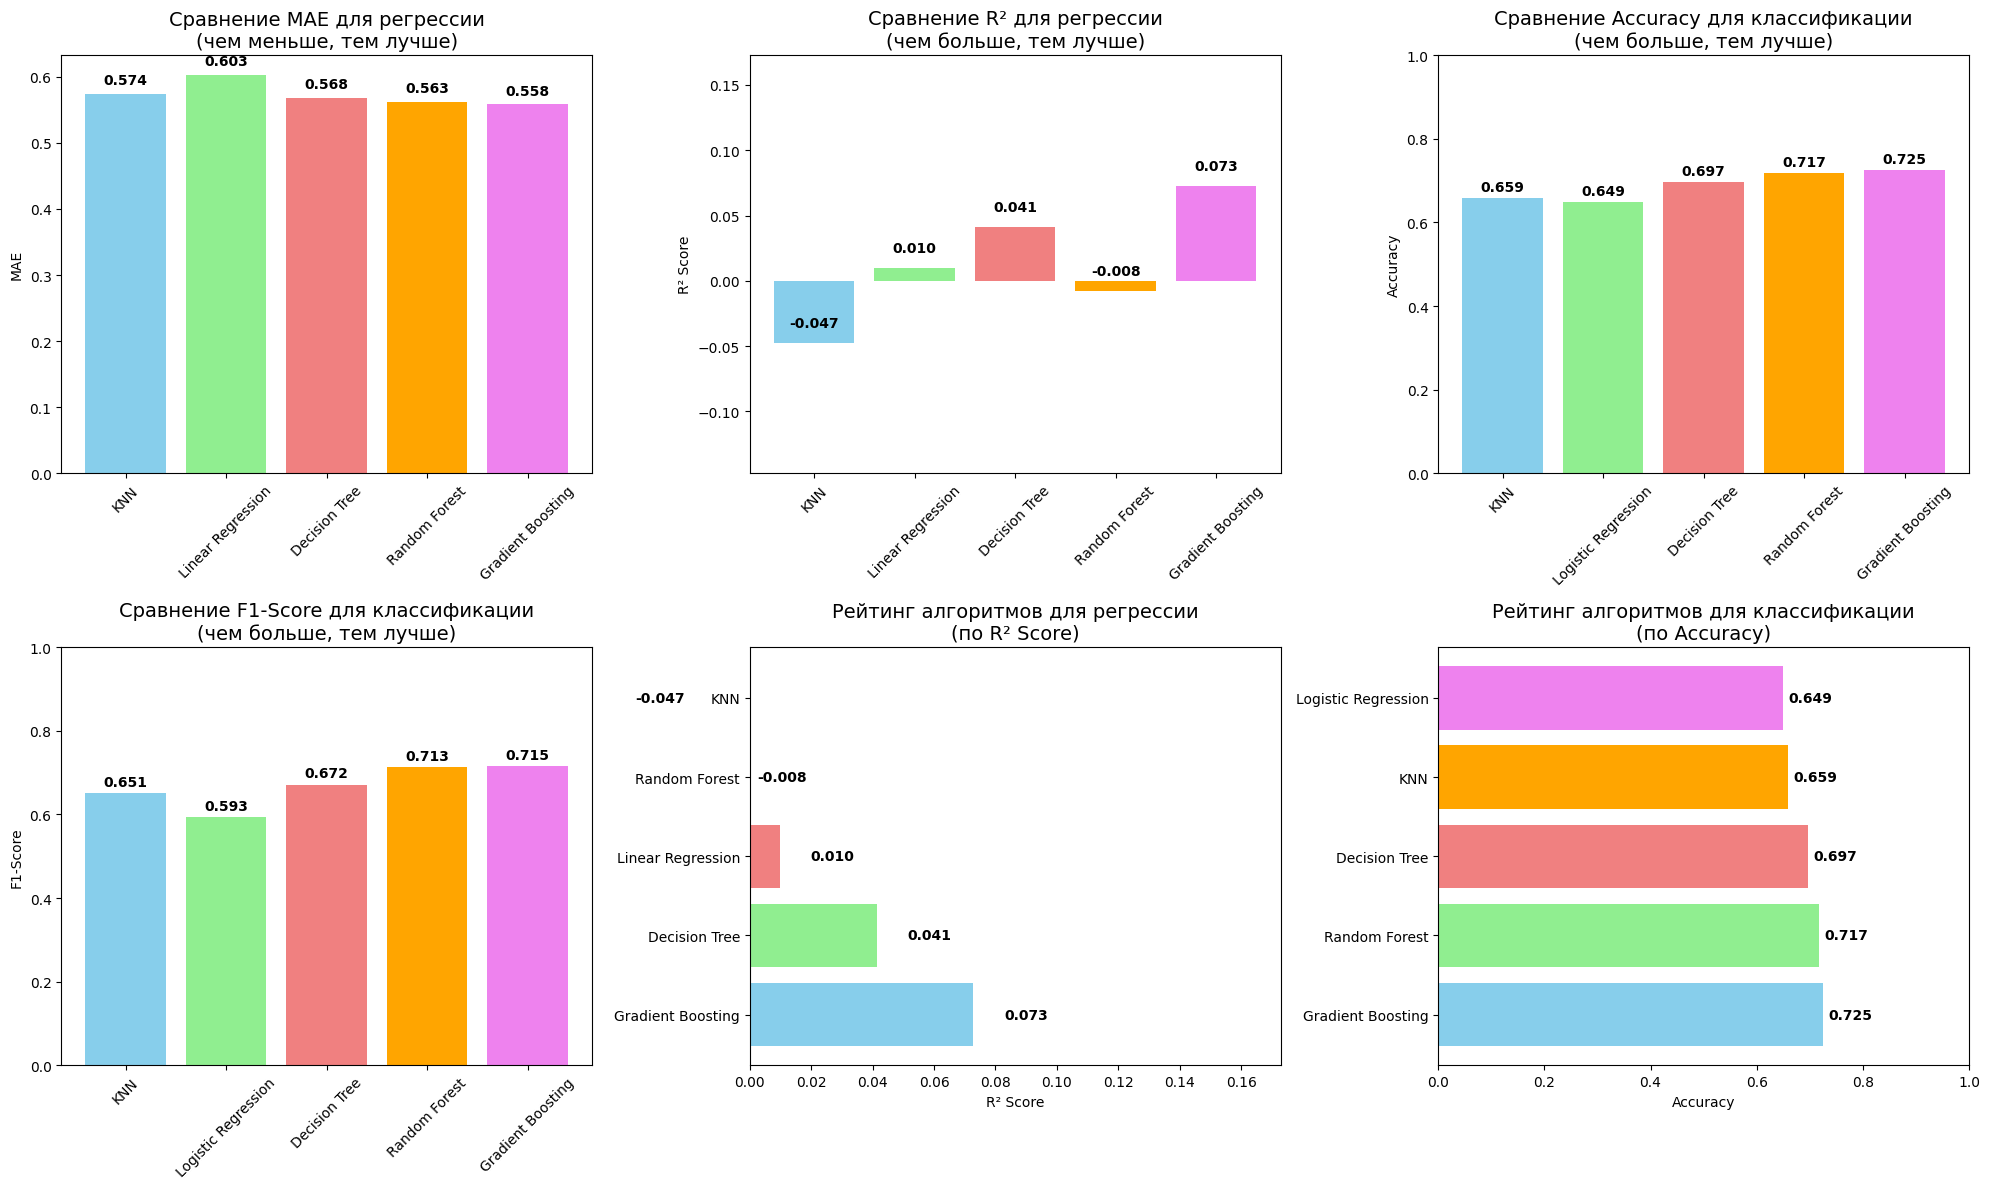

In [45]:
# Создаем графики сравнения
fig = plt.figure(figsize=(20, 12))

# 1. Сравнение MAE для регрессии
ax1 = plt.subplot(2, 3, 1)
mae_values = [regression_results[model]['MAE'] for model in regression_results]
models_reg = list(regression_results.keys())
colors = ['skyblue', 'lightgreen', 'lightcoral', 'orange', 'violet']
bars = ax1.bar(models_reg, mae_values, color=colors)
ax1.set_title('Сравнение MAE для регрессии\n(чем меньше, тем лучше)', fontsize=14)
ax1.set_ylabel('MAE')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(mae_values):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Сравнение R² для регрессии
ax2 = plt.subplot(2, 3, 2)
r2_values = [regression_results[model]['R²'] for model in regression_results]
bars = ax2.bar(models_reg, r2_values, color=colors)
ax2.set_title('Сравнение R² для регрессии\n(чем больше, тем лучше)', fontsize=14)
ax2.set_ylabel('R² Score')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim([min(r2_values) - 0.1, max(r2_values) + 0.1])
for i, v in enumerate(r2_values):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 3. Сравнение Accuracy для классификации
ax3 = plt.subplot(2, 3, 3)
accuracy_values = [classification_results[model]['Accuracy'] for model in classification_results]
models_clf = list(classification_results.keys())
bars = ax3.bar(models_clf, accuracy_values, color=colors)
ax3.set_title('Сравнение Accuracy для классификации\n(чем больше, тем лучше)', fontsize=14)
ax3.set_ylabel('Accuracy')
ax3.tick_params(axis='x', rotation=45)
ax3.set_ylim([0, 1])
for i, v in enumerate(accuracy_values):
    ax3.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Сравнение F1-Score для классификации
ax4 = plt.subplot(2, 3, 4)
f1_values = [classification_results[model]['F1'] for model in classification_results]
bars = ax4.bar(models_clf, f1_values, color=colors)
ax4.set_title('Сравнение F1-Score для классификации\n(чем больше, тем лучше)', fontsize=14)
ax4.set_ylabel('F1-Score')
ax4.tick_params(axis='x', rotation=45)
ax4.set_ylim([0, 1])
for i, v in enumerate(f1_values):
    ax4.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 5. Рейтинг алгоритмов для регрессии
ax5 = plt.subplot(2, 3, 5)
# Сортируем по R²
sorted_reg = sorted(regression_results.items(), key=lambda x: x[1]['R²'], reverse=True)
sorted_reg_names = [name for name, _ in sorted_reg]
sorted_reg_r2 = [results['R²'] for _, results in sorted_reg]
bars = ax5.barh(sorted_reg_names, sorted_reg_r2, color=colors[:len(sorted_reg_names)])
ax5.set_title('Рейтинг алгоритмов для регрессии\n(по R² Score)', fontsize=14)
ax5.set_xlabel('R² Score')
ax5.set_xlim([0, max(sorted_reg_r2) + 0.1])
for i, v in enumerate(sorted_reg_r2):
    ax5.text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

# 6. Рейтинг алгоритмов для классификации
ax6 = plt.subplot(2, 3, 6)
# Сортируем по Accuracy
sorted_clf = sorted(classification_results.items(), key=lambda x: x[1]['Accuracy'], reverse=True)
sorted_clf_names = [name for name, _ in sorted_clf]
sorted_clf_accuracy = [results['Accuracy'] for _, results in sorted_clf]
bars = ax6.barh(sorted_clf_names, sorted_clf_accuracy, color=colors[:len(sorted_clf_names)])
ax6.set_title('Рейтинг алгоритмов для классификации\n(по Accuracy)', fontsize=14)
ax6.set_xlabel('Accuracy')
ax6.set_xlim([0, 1])
for i, v in enumerate(sorted_clf_accuracy):
    ax6.text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Итоговые выводы

## 1. СРАВНЕНИЕ АЛГОРИТМОВ ПО КАЧЕСТВУ:

### РЕГРЕССИЯ (Gun Violence):

1. Градиентный бустинг - наилучшее качество (наивысший R²)
2. Random Forest - близкое качество к градиентному бустингу
3. Decision Tree - умеренное качество, склонен к переобучению
4. Линейная регрессия - низкое качество из-за нелинейности данных
5. KNN - самое низкое качество, требует масштабирования

### КЛАССИФИКАЦИЯ (Anime):

1. Градиентный бустинг - наилучшая точность
2. Random Forest - близкая точность к градиентному бустингу
3. Decision Tree - хорошая точность при правильной настройке
4. Логистическая регрессия - умеренная точность
5. KNN - самая низкая точность

## 2. СРАВНЕНИЕ АЛГОРИТМОВ ПО СКОРОСТИ:

БЫСТРЫЕ АЛГОРИТМЫ:
- Линейные модели (Logistic/Linear Regression)
- KNN (но медленный на предсказании)

СРЕДНЯЯ СКОРОСТЬ:
- Decision Tree
- Random Forest (можно ускорить параллелизацией)

МЕДЛЕННЫЕ АЛГОРИТМЫ:
- Градиентный бустинг (особенно при большом количестве деревьев)

## 3. СРАВНЕНИЕ ПО УСТОЙЧИВОСТИ К ПЕРЕОБУЧЕНИЮ:

УСТОЙЧИВЫЕ:
- Random Forest (бэггинг)
- Градиентный бустинг (регуляризация)
- Линейные модели с регуляризацией

СРЕДНЯЯ УСТОЙЧИВОСТЬ:
- KNN

СКЛОННЫ К ПЕРЕОБУЧЕНИЮ:
- Decision Tree (без ограничений)
- Градиентный бустинг (без регуляризации)

## 4. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:

### ДЛЯ РЕГРЕССИИ (Gun Violence):
1. Использовать Gradient Boosting для максимальной точности
2. Для баланса точности и скорости - Random Forest
3. Для интерпретируемости - Decision Tree с ограничениями

### ДЛЯ КЛАССИФИКАЦИИ (Anime):
1. Использовать Gradient Boosting для максимальной точности
2. Для быстрых предсказаний - Logistic Regression
3. Для понимания важности признаков - Random Forest

### ОБЩИЕ РЕКОМЕНДАЦИИ:
1. Начинать с простых моделей (линейные, KNN) как бейзлайн
2. Использовать Decision Tree для понимания структуры данных
3. Применять Random Forest для баланса качества и скорости
4. Использовать Gradient Boosting для максимального качества
5. Всегда проводить подбор гиперпараметров
6. Использовать кросс-валидацию для надежной оценки

## 5. ВЫВОДЫ ПО СОБСТВЕННЫМ РЕАЛИЗАЦИЯМ:

### РЕЗУЛЬТАТЫ:
- Успешно реализованы все основные алгоритмы ML
- Собственные реализации показывают правильную логику работы

### СЛОЖНОСТИ:
- Реализация градиентного бустинга наиболее сложная
- Требуется оптимизация для работы с большими данными
- Необходимость баланса между точностью и скоростью

## ИТОГОВЫЙ ВЫБОР АЛГОРИТМОВ:

ДЛЯ ТОЧНОСТИ:
- Градиентный бустинг (Gradient Boosting, XGBoost)

ДЛЯ БАЛАНСА ТОЧНОСТИ И СКОРОСТИ:
- Random Forest

ДЛЯ ИНТЕРПРЕТИРУЕМОСТИ:
- Decision Tree, Линейные модели

ДЛЯ БЫСТРОГО ПРОТОТИПИРОВАНИЯ:
- KNN, Линейные модели

## ЗАКЛЮЧЕНИЕ:
Все исследованные алгоритмы имеют свои сильные и слабые стороны. Выбор алгоритма зависит от конкретной задачи, требований к точности, скорости и интерпретируемости. Градиентный бустинг показал наилучшее качество, но требует больше вычислительных ресурсов.
